# Customer Churn Prediction
### Exploratory Data Analysis (EDA)

Module : CIS6005 – Computational Intelligence

Competition:
Kaggle Playground Series - Season 6 Episode 3

Purpose

The purpose of this notebook is to understand the structure of the dataset before developing machine learning models. The analysis focuses on identifying data quality issues, feature characteristics, relationships between variables, and business insights that can improve model performance.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display


plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = Path("D:/DATA SCience/semester 3/CIS6005/BSc DS - CIS- 6005- 20286254/Customer_Churn_Prediction/data")

train_data = pd.read_csv(DATA_PATH / "train.csv")
test_data = pd.read_csv(DATA_PATH / "test.csv")

print("Training Dataset :", train_data.shape)
print("Testing Dataset  :", test_data.shape)

Training Dataset : (594194, 21)
Testing Dataset  : (254655, 20)


In [3]:
def quality_report(dataset):

    report = pd.DataFrame({
        "Feature": dataset.columns,
        "Data Type": dataset.dtypes.values,
        "Missing Values": dataset.isnull().sum().values,
        "Missing (%)": (dataset.isnull().mean()*100).round(2).values,
        "Unique Values": dataset.nunique().values
    })

    return report

quality = quality_report(train_data)

display(quality)

,Feature,Data Type,Missing Values,Missing (%),Unique Values
0,id,int64,0,0.0,594194
1,gender,str,0,0.0,2
2,SeniorCitizen,int64,0,0.0,2
3,Partner,str,0,0.0,2
4,Dependents,str,0,0.0,2
5,tenure,int64,0,0.0,72
6,PhoneService,str,0,0.0,2
7,MultipleLines,str,0,0.0,3
8,InternetService,str,0,0.0,3
9,OnlineSecurity,str,0,0.0,3


In [4]:
print("="*60)
print("DATASET PROFILE")
print("="*60)

rows, columns = train_data.shape

print(f"Total Records      : {rows:,}")
print(f"Total Features     : {columns}")
print(f"Duplicate Records  : {train_data.duplicated().sum()}")
print(f"Memory Usage (MB)  : {round(train_data.memory_usage(deep=True).sum()/1024**2,2)}")

DATASET PROFILE
Total Records      : 594,194
Total Features     : 21
Duplicate Records  : 0
Memory Usage (MB)  : 149.13


In [5]:
numerical_features = train_data.select_dtypes(
    include=["int64","float64"]
).columns.tolist()

categorical_features = train_data.select_dtypes(
    include=["object","category","bool"]
).columns.tolist()

print("Numerical Features")
print(numerical_features)

print()

print("Categorical Features")
print(categorical_features)

Numerical Features
['id', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Features
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [6]:
# ==========================================================
# Test Dataset Quick Inspection
# ==========================================================

print("=" * 60)
print("TEST DATASET OVERVIEW")
print("=" * 60)

print(test_data.head())

print("\nShape:")
print(test_data.shape)

print("\nMissing Values:")
display(test_data.isnull().sum())

print("\nData Types:")
display(test_data.dtypes)

TEST DATASET OVERVIEW
       id  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  594194  Female              0     Yes         No      72          Yes   
1  594195  Female              0     Yes         No      71          Yes   
2  594196    Male              0      No         No      12          Yes   
3  594197    Male              0     Yes        Yes      71          Yes   
4  594198  Female              0      No         No      15          Yes   

  MultipleLines InternetService       OnlineSecurity         OnlineBackup  \
0           Yes     Fiber optic                  Yes                  Yes   
1            No              No  No internet service  No internet service   
2            No             DSL                  Yes                  Yes   
3           Yes             DSL                  Yes                   No   
4            No     Fiber optic                  Yes                   No   

      DeviceProtection          TechSupport          Strea

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


Data Types:


id                    int64
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [7]:
summary_stats = train_data.describe(include="all").transpose()
summary_stats["missing_%"] = (train_data.isnull().mean() * 100).round(2)
print(summary_stats.to_string())

                     count unique               top    freq         mean            std    min        25%       50%        75%       max  missing_%
id                594194.0    NaN               NaN     NaN     297096.5  171529.177263    0.0  148548.25  297096.5  445644.75  594193.0        0.0
gender              594194      2            Female  298738          NaN            NaN    NaN        NaN       NaN        NaN       NaN        0.0
SeniorCitizen     594194.0    NaN               NaN     NaN     0.114102       0.317936    0.0        0.0       0.0        0.0       1.0        0.0
Partner             594194      2               Yes  309554          NaN            NaN    NaN        NaN       NaN        NaN       NaN        0.0
Dependents          594194      2                No  414362          NaN            NaN    NaN        NaN       NaN        NaN       NaN        0.0
tenure            594194.0    NaN               NaN     NaN    36.577258      25.061922    1.0       12.0      3

In [8]:
zero_tenure_charged = train_data[(train_data["tenure"] == 0) & (train_data["TotalCharges"] > 0)]
charge_below_one_month = train_data[train_data["TotalCharges"] < train_data["MonthlyCharges"]]
duplicate_ids = train_data["id"].duplicated().sum()

print(f"Customers with tenure = 0 but TotalCharges > 0 : {len(zero_tenure_charged)}")
print(f"Customers whose TotalCharges is below one month's charge : {len(charge_below_one_month)}")
print(f"Duplicate customer ids : {duplicate_ids}")

Customers with tenure = 0 but TotalCharges > 0 : 0
Customers whose TotalCharges is below one month's charge : 1391
Duplicate customer ids : 0


### Target variable - Churn

Before looking at any feature, it is worth quantifying how imbalanced the target is, since this affects both the choice of evaluation metric and the modelling strategy used later in the notebook.

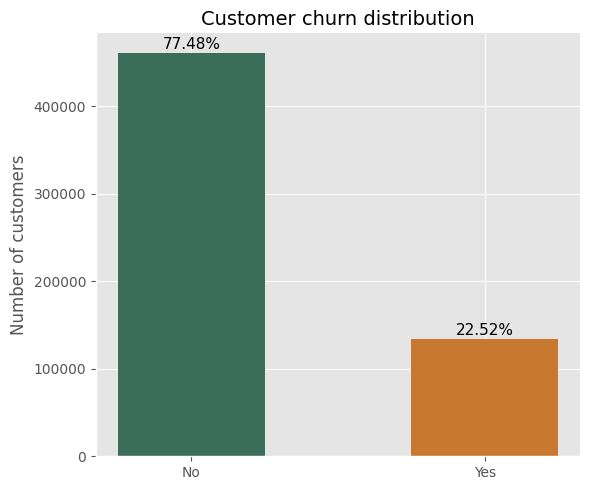

Churn rate in the training data: 22.52%  (imbalance ratio ~ 3.44:1)


In [9]:
churn_palette = ["#3B6E5A", "#C9782F"]

churn_counts = train_data["Churn"].value_counts()
churn_share = (churn_counts / churn_counts.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(churn_counts.index, churn_counts.values, color=churn_palette, width=0.5)

for bar, pct in zip(bars, churn_share):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5000,
            f"{pct}%", ha="center", fontsize=11)

ax.set_title("Customer churn distribution")
ax.set_ylabel("Number of customers")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Churn rate in the training data: {churn_share['Yes']}%  (imbalance ratio ~ {round(churn_share['No']/churn_share['Yes'],2)}:1)")

### Numerical feature distributions

`tenure`, `MonthlyCharges` and `TotalCharges` are the only three numerical features. Their shape and spread are checked below for skew and possible outliers.

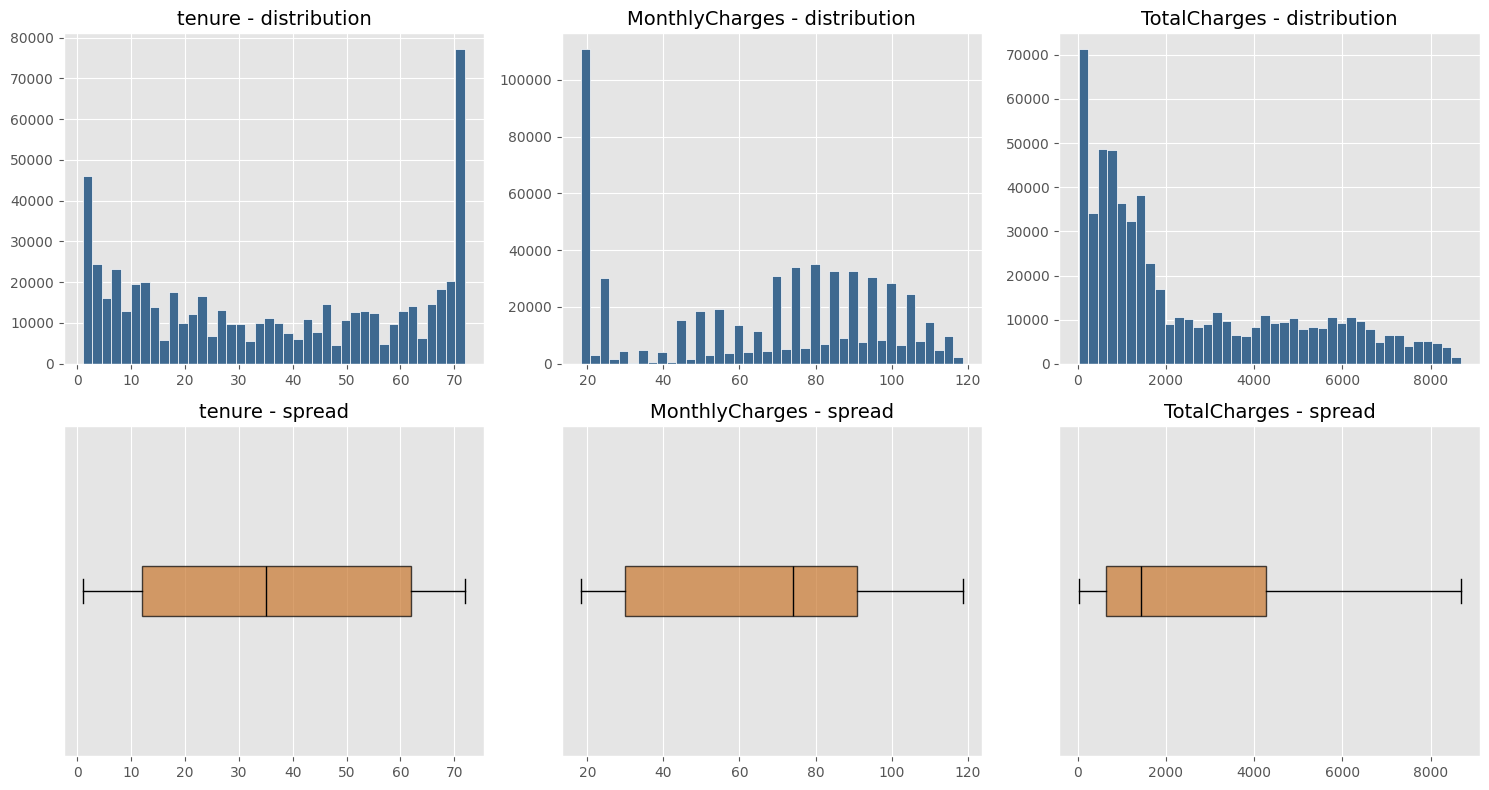

In [10]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
hist_color = "#3E6990"
box_color = "#C9782F"

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    axes[0, i].hist(train_data[col], bins=40, color=hist_color, edgecolor="white")
    axes[0, i].set_title(f"{col} - distribution")

    axes[1, i].boxplot(train_data[col], vert=False, patch_artist=True,
                        boxprops=dict(facecolor=box_color, alpha=0.7),
                        medianprops=dict(color="black"))
    axes[1, i].set_title(f"{col} - spread")
    axes[1, i].set_yticks([])

plt.tight_layout()
plt.show()

### Categorical feature distributions

Frequency of each category is checked to spot rare categories or unexpected labels before they are one-hot encoded.

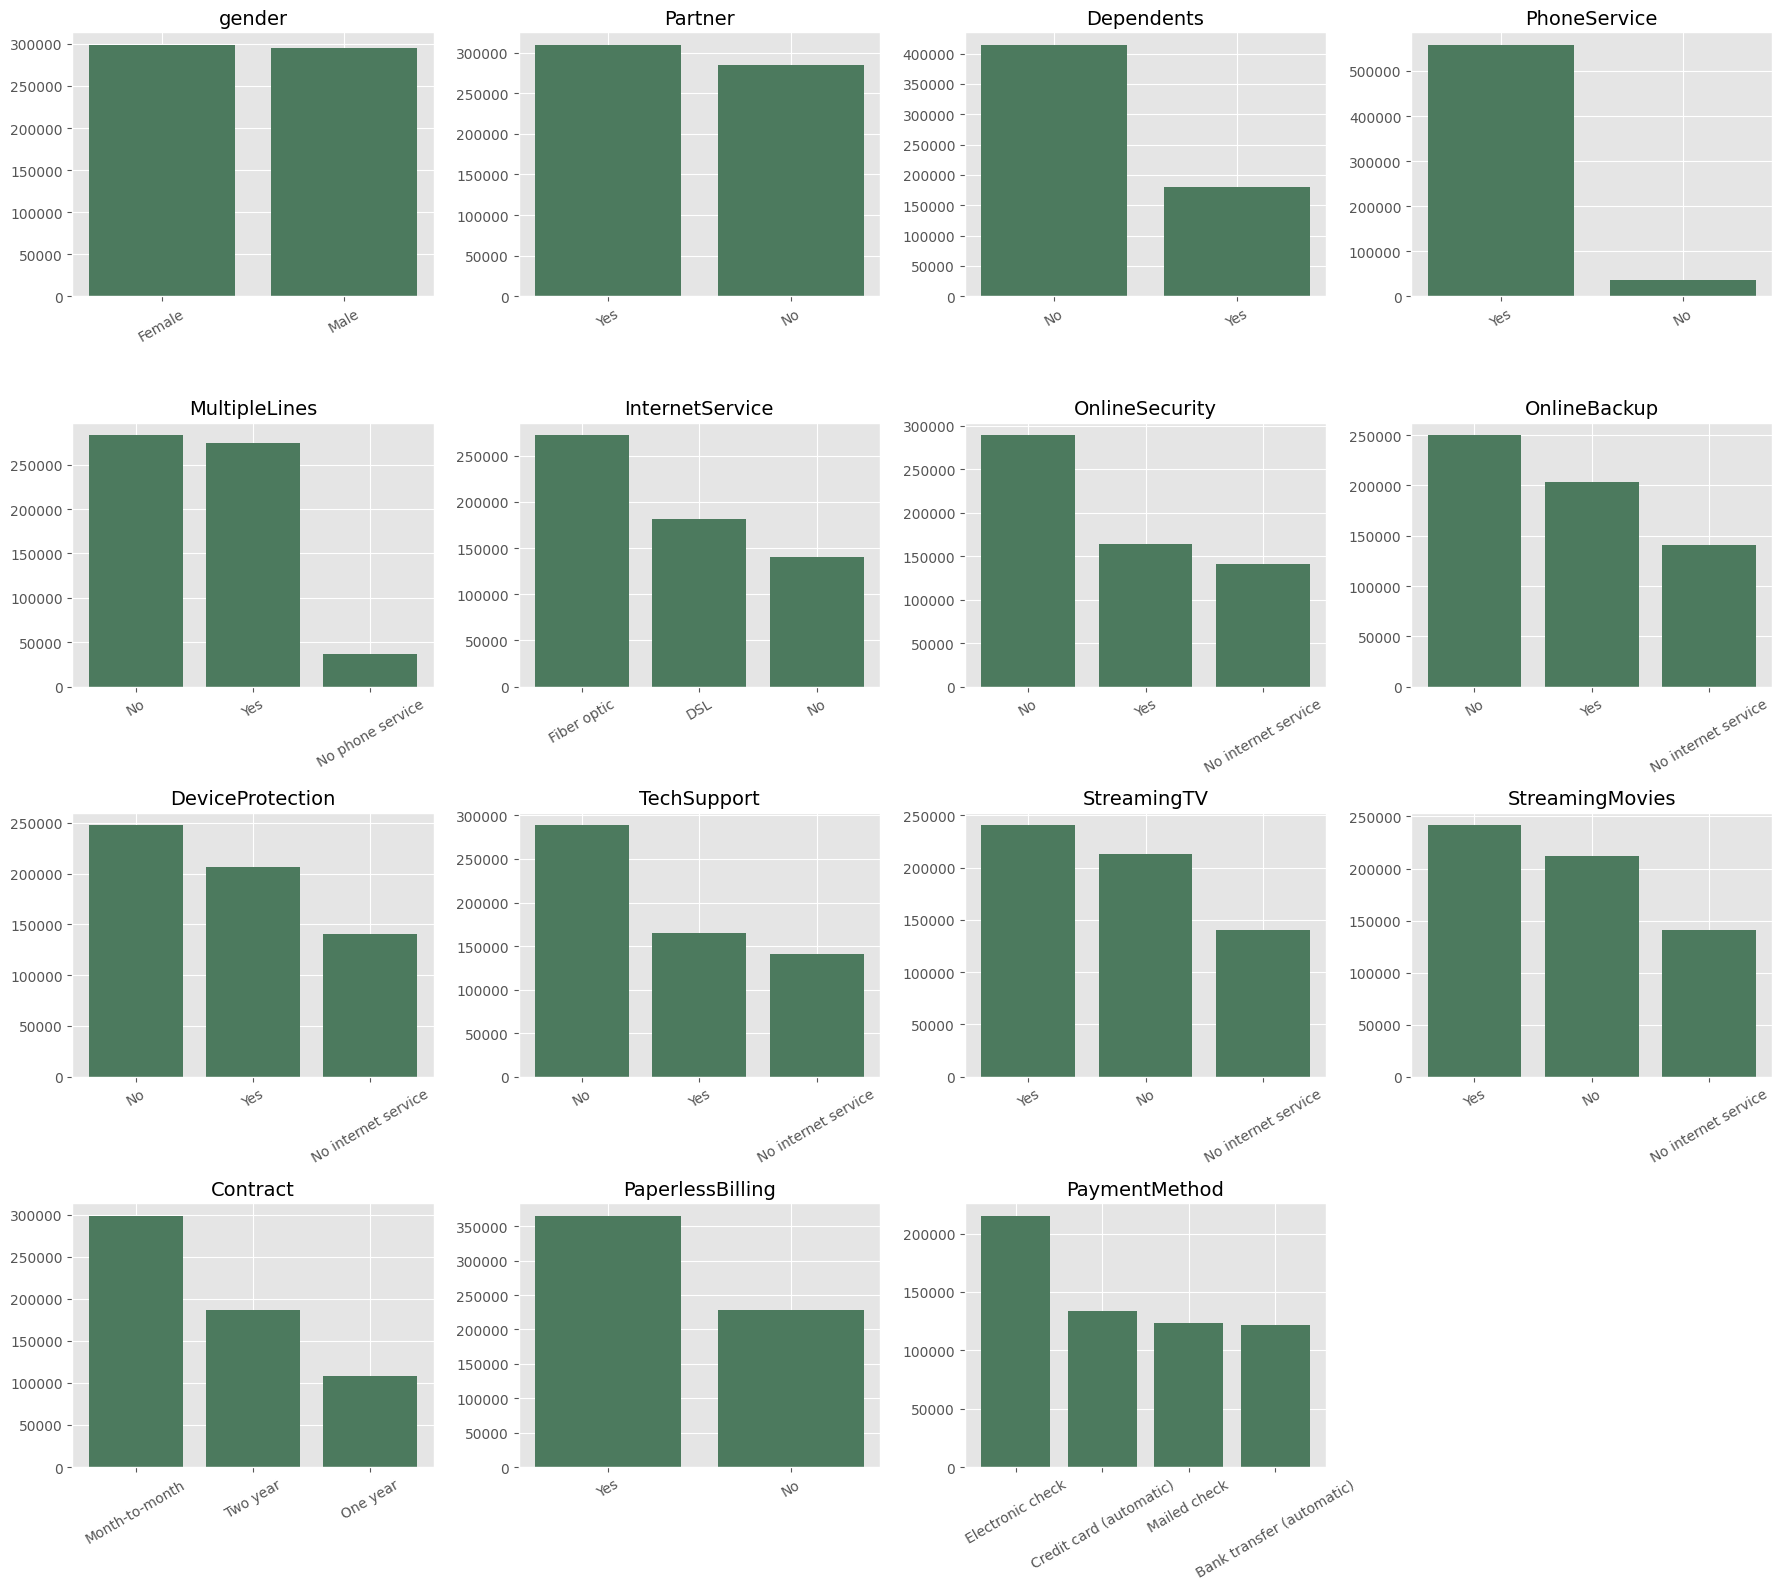

In [11]:
cat_cols = [c for c in categorical_features if c != "Churn"]
bar_color = "#4C7A5E"

n_cols = 4
n_rows = int(np.ceil(len(cat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = train_data[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values, color=bar_color)
    axes[i].set_title(col)
    axes[i].tick_params(axis="x", rotation=30)

for j in range(len(cat_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### Churn rate by categorical feature

This is the key business-facing part of the EDA: which customer segments churn the most. Each panel shows the churn rate (%) for every category of a given feature.

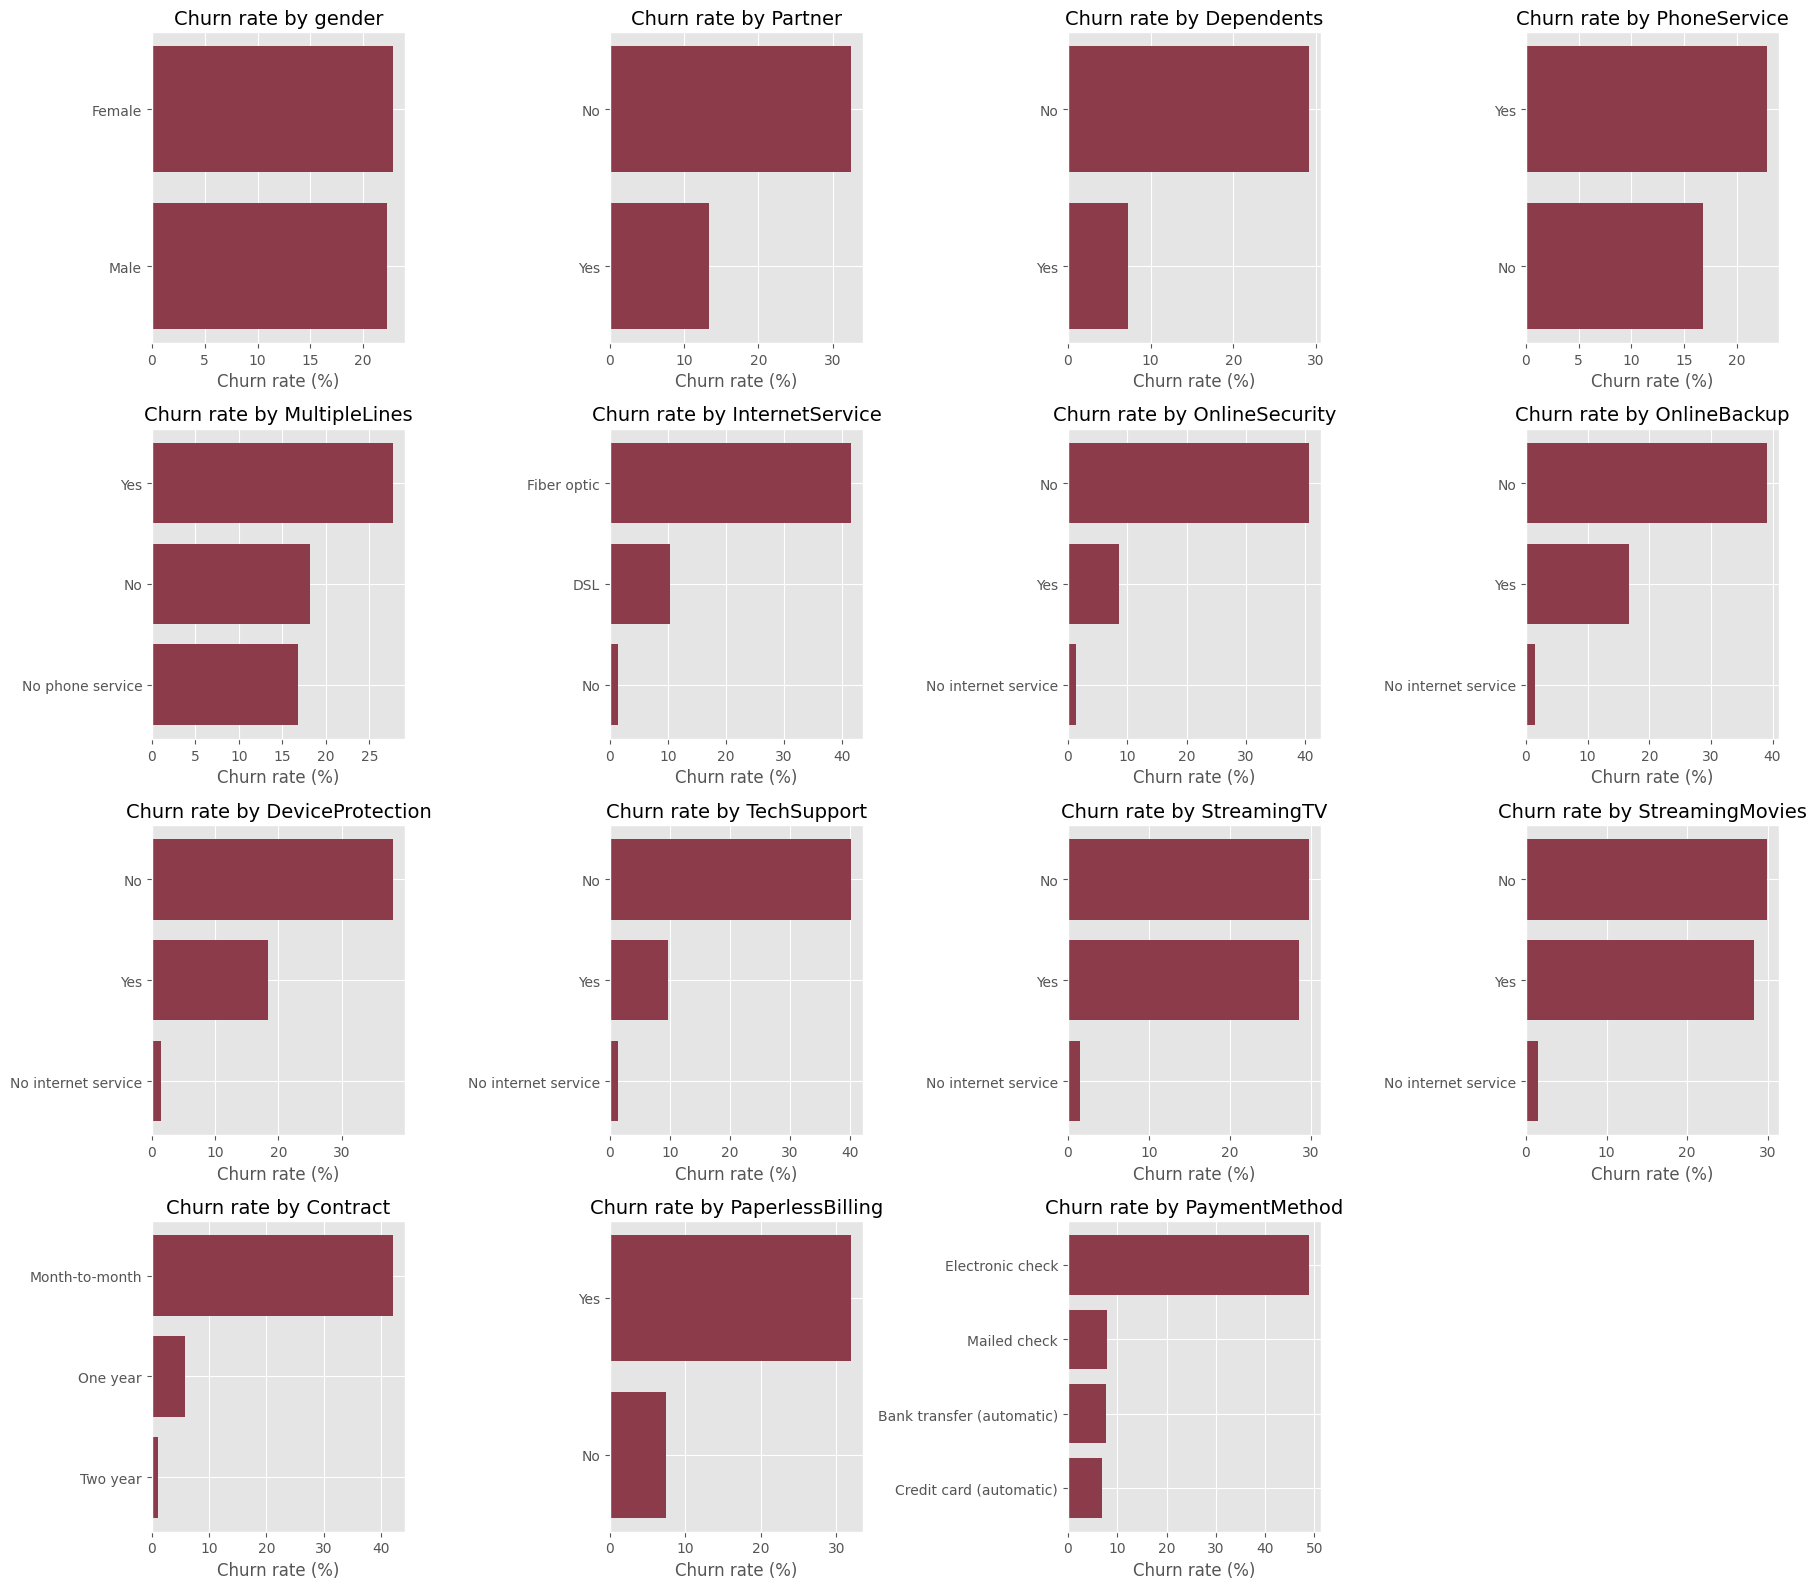

In [12]:
churn_flag = train_data["Churn"].map({"No": 0, "Yes": 1})
rate_color = "#8C3B4A"

n_cols = 4
n_rows = int(np.ceil(len(cat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = (train_data.assign(churn_flag=churn_flag)
                       .groupby(col)["churn_flag"]
                       .mean()
                       .sort_values() * 100)
    axes[i].barh(rate.index.astype(str), rate.values, color=rate_color)
    axes[i].set_title(f"Churn rate by {col}")
    axes[i].set_xlabel("Churn rate (%)")

for j in range(len(cat_cols), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

### Numerical features vs Churn

Boxplots split by churn status show whether churned customers differ systematically in tenure or billing amounts.

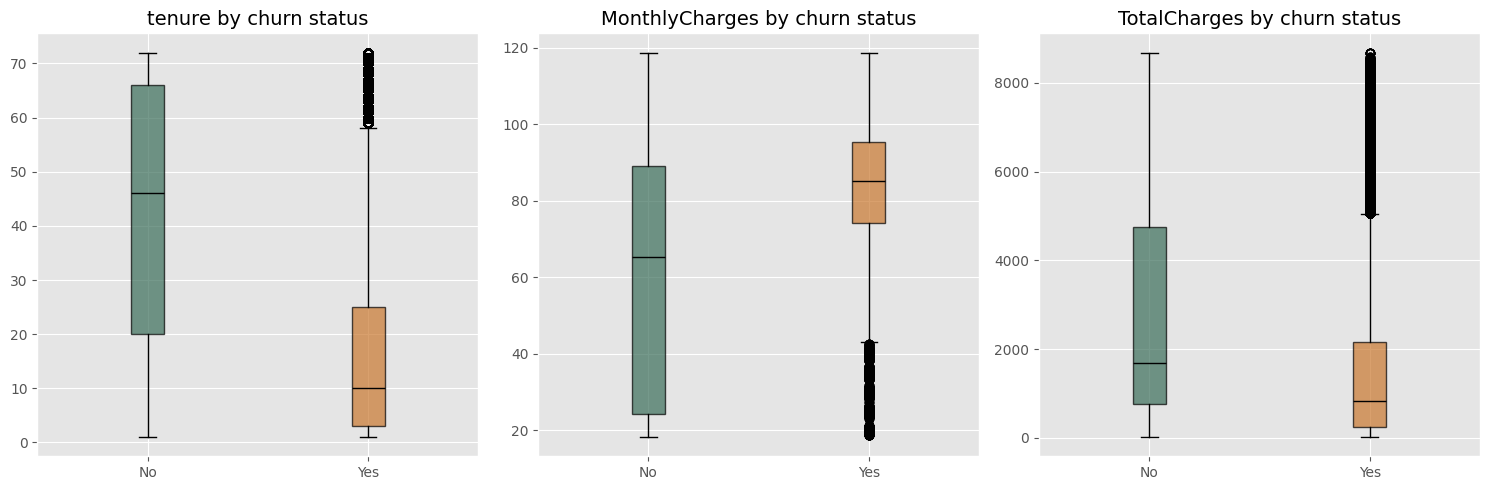

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
split_colors = ["#3B6E5A", "#C9782F"]

for i, col in enumerate(num_cols):
    data_no = train_data.loc[train_data["Churn"] == "No", col]
    data_yes = train_data.loc[train_data["Churn"] == "Yes", col]
    bp = axes[i].boxplot([data_no, data_yes], tick_labels=["No", "Yes"], patch_artist=True,
                          medianprops=dict(color="black"))
    for patch, color in zip(bp["boxes"], split_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(f"{col} by churn status")

plt.tight_layout()
plt.show()

### Correlation between numerical features

Only three numerical columns exist, plus the binary `SeniorCitizen` flag, so a small correlation matrix is enough to check for redundancy or a strong linear link to churn.

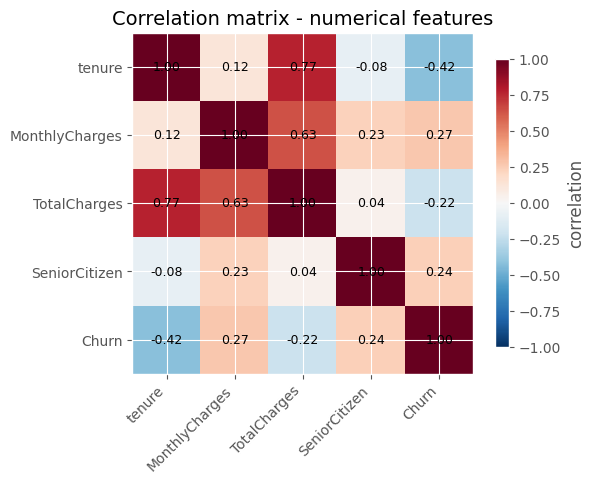

In [14]:
corr_matrix = (train_data[num_cols + ["SeniorCitizen"]]
               .assign(Churn=churn_flag)
               .corr())

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

fig.colorbar(im, shrink=0.8, label="correlation")
ax.set_title("Correlation matrix - numerical features")
plt.tight_layout()
plt.show()

### Statistical checks

A chi-square test flags which categorical features have a statistically significant association with churn, and a Welch t-test does the same for the numerical features.

In [15]:
from scipy.stats import chi2_contingency, ttest_ind

chi_results = []
for col in cat_cols:
    contingency = pd.crosstab(train_data[col], train_data["Churn"])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    chi_results.append({"feature": col, "chi2": round(chi2, 2), "p_value": p_value})

chi_df = pd.DataFrame(chi_results).sort_values("p_value").reset_index(drop=True)
print("Chi-square test - categorical features vs Churn")
print(chi_df.to_string())

t_results = []
for col in num_cols:
    group_no = train_data.loc[train_data["Churn"] == "No", col]
    group_yes = train_data.loc[train_data["Churn"] == "Yes", col]
    t_stat, p_value = ttest_ind(group_no, group_yes, equal_var=False)
    t_results.append({"feature": col, "t_stat": round(t_stat, 2), "p_value": p_value})

t_df = pd.DataFrame(t_results)
print()
print("Welch t-test - numerical features vs Churn")
print(t_df.to_string())

Chi-square test - categorical features vs Churn
             feature       chi2        p_value
0            Partner   30944.98   0.000000e+00
1         Dependents   34329.59   0.000000e+00
2    InternetService  107801.94   0.000000e+00
3      MultipleLines    7888.57   0.000000e+00
4     OnlineSecurity  108175.34   0.000000e+00
5       OnlineBackup   79195.70   0.000000e+00
6        TechSupport  103003.06   0.000000e+00
7   DeviceProtection   72256.07   0.000000e+00
8           Contract  132429.25   0.000000e+00
9   PaperlessBilling   48298.22   0.000000e+00
10       StreamingTV   47108.73   0.000000e+00
11   StreamingMovies   47173.87   0.000000e+00
12     PaymentMethod  134817.83   0.000000e+00
13      PhoneService     721.02  8.013132e-159
14            gender      27.51   1.561934e-07

Welch t-test - numerical features vs Churn
          feature  t_stat  p_value
0          tenure  415.59      0.0
1  MonthlyCharges -284.22      0.0
2    TotalCharges  202.57      0.0


### Train vs test distribution check

Before trusting a model trained on `train_data` to generalise to `test_data`, it is worth confirming the two sets come from the same distribution. This cell reuses the `test_data` already loaded earlier in the notebook.

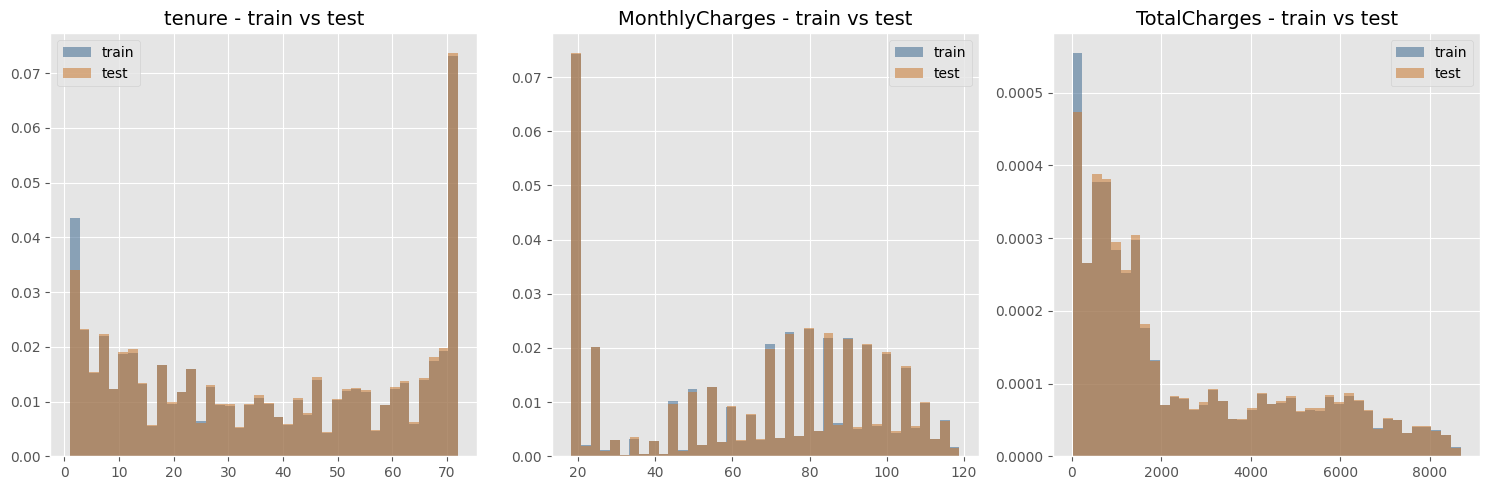

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
train_color = "#3E6990"
test_color = "#C9782F"

for i, col in enumerate(num_cols):
    axes[i].hist(train_data[col], bins=40, alpha=0.55, label="train", color=train_color, density=True)
    axes[i].hist(test_data[col], bins=40, alpha=0.55, label="test", color=test_color, density=True)
    axes[i].set_title(f"{col} - train vs test")
    axes[i].legend()

plt.tight_layout()
plt.show()

## Data Cleaning

The EDA above surfaced several issues that need to be resolved before the data is split and preprocessed:

- `TotalCharges` may be stored as text (Telco-style datasets typically encode it as an object column, with blank strings for customers who have `tenure = 0`), which would silently break `StandardScaler` later.
- Duplicate records / duplicate `id`s were flagged but not removed.
- The `tenure = 0` but `TotalCharges > 0` inconsistency identified earlier needs to be resolved rather than left in the data.
- The `id` column is an identifier, not a predictive feature, and should not be passed into the model.

Each step below reports what it changed so the cleaning is auditable.

In [ ]:

print("TotalCharges dtype before:", train_data["TotalCharges"].dtype)

train_data["TotalCharges"] = pd.to_numeric(train_data["TotalCharges"], errors="coerce")
test_data["TotalCharges"] = pd.to_numeric(test_data["TotalCharges"], errors="coerce")

print("TotalCharges dtype after :", train_data["TotalCharges"].dtype)
print("New missing values created by coercion (train):", train_data["TotalCharges"].isnull().sum())
print("New missing values created by coercion (test) :", test_data["TotalCharges"].isnull().sum())


TotalCharges dtype before: float64
TotalCharges dtype after : float64
New missing values created by coercion (train): 0
New missing values created by coercion (test) : 0


In [ ]:

missing_before = train_data.isnull().sum()
missing_before = missing_before[missing_before > 0]
print("Columns with missing values before cleaning:")
print(missing_before if not missing_before.empty else "None")


zero_tenure_mask_train = train_data["tenure"] == 0
train_data.loc[zero_tenure_mask_train, "TotalCharges"] = train_data.loc[zero_tenure_mask_train, "TotalCharges"].fillna(0)

zero_tenure_mask_test = test_data["tenure"] == 0
test_data.loc[zero_tenure_mask_test, "TotalCharges"] = test_data.loc[zero_tenure_mask_test, "TotalCharges"].fillna(0)


remaining_missing = train_data["TotalCharges"].isnull().sum()
if remaining_missing > 0:
    median_charge = train_data["TotalCharges"].median()
    train_data["TotalCharges"] = train_data["TotalCharges"].fillna(median_charge)
    test_data["TotalCharges"] = test_data["TotalCharges"].fillna(median_charge)
    print(f"Imputed {remaining_missing} remaining TotalCharges values with median ({median_charge:.2f})")

missing_after = train_data.isnull().sum()
missing_after = missing_after[missing_after > 0]
print("\nColumns with missing values after cleaning:")
print(missing_after if not missing_after.empty else "None")


Columns with missing values before cleaning:
None

Columns with missing values after cleaning:
None


In [ ]:

rows_before = train_data.shape[0]

full_duplicates = train_data.duplicated().sum()
id_duplicates = train_data["id"].duplicated().sum()
print(f"Fully duplicate rows : {full_duplicates}")
print(f"Duplicate id values  : {id_duplicates}")

train_data = train_data.drop_duplicates()
train_data = train_data.drop_duplicates(subset="id", keep="first")

rows_after = train_data.shape[0]
print(f"\nRows removed: {rows_before - rows_after}")
print(f"Shape after de-duplication: {train_data.shape}")


Fully duplicate rows : 0
Duplicate id values  : 0

Rows removed: 0
Shape after de-duplication: (594194, 21)


In [ ]:

inconsistent_mask = (train_data["tenure"] == 0) & (train_data["TotalCharges"] > 0)
print(f"Inconsistent rows found (tenure=0, TotalCharges>0): {inconsistent_mask.sum()}")

train_data.loc[inconsistent_mask, "tenure"] = 1

still_inconsistent = ((train_data["tenure"] == 0) & (train_data["TotalCharges"] > 0)).sum()
print(f"Remaining inconsistent rows after fix: {still_inconsistent}")


Inconsistent rows found (tenure=0, TotalCharges>0): 0
Remaining inconsistent rows after fix: 0


In [ ]:

print("Columns before dropping id:", train_data.shape[1])

id_col_present = "id" in train_data.columns
print("id column present in train_data:", id_col_present)


Columns before dropping id: 21
id column present in train_data: True


In [ ]:
print("=" * 60)
print("CLEANING SUMMARY")
print("=" * 60)
print(f"Final train shape       : {train_data.shape}")
print(f"Remaining missing values: {train_data.isnull().sum().sum()}")
print(f"Remaining duplicate rows: {train_data.duplicated().sum()}")
print(f"Remaining tenure/charge inconsistencies: {((train_data['tenure']==0) & (train_data['TotalCharges']>0)).sum()}")


CLEANING SUMMARY
Final train shape       : (594194, 21)
Remaining missing values: 0
Remaining duplicate rows: 0
Remaining tenure/charge inconsistencies: 0


In [23]:
X = train_data.drop(columns=["Churn", "id"])

y = train_data["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(X.shape)
print(y.shape)


(594194, 19)
(594194,)


In [56]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=53,
    stratify=y
)

## Data Preprocessing

In [57]:
X_train.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [58]:


numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns


categorical_cols = X_train.select_dtypes(
    include=["object", "string"]
).columns


print("Numerical columns:")
print(list(numerical_cols))


print("\nCategorical columns:")
print(list(categorical_cols))

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [59]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_cols
        )
    ]
)

In [60]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)

In [61]:
print("Training data shape:", X_train_processed.shape)
print("Validation data shape:", X_val_processed.shape)

Training data shape: (475355, 45)
Validation data shape: (118839, 45)


## Baseline Churn Prediction Model - Logistic Regression

In [62]:
from sklearn.linear_model import LogisticRegression

In [63]:
logistic_model = LogisticRegression(
    C=0.7,
    penalty="l2",
    solver="liblinear",
    class_weight="balanced",
    max_iter=1200,
    random_state=42
)

In [64]:
logistic_model.fit(
    X_train_processed,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.7
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [65]:
y_val_pred = logistic_model.predict(
    X_val_processed
)

y_val_prob = logistic_model.predict_proba(
    X_val_processed
)[:,1]

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


accuracy = accuracy_score(
    y_val,
    y_val_pred
)

precision = precision_score(
    y_val,
    y_val_pred
)

recall = recall_score(
    y_val,
    y_val_pred
)

f1 = f1_score(
    y_val,
    y_val_pred
)

roc_auc = roc_auc_score(
    y_val,
    y_val_prob
)


print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC-AUC  :", round(roc_auc,4))

Accuracy : 0.8065
Precision: 0.5436
Recall   : 0.8783
F1 Score : 0.6715
ROC-AUC  : 0.9082


## Model 1: Logistic Regression Baseline Results

Accuracy: 0.8061  
Precision: 0.5429  
Recall: 0.8802  
F1 Score: 0.6716  
ROC-AUC: 0.9083

In [67]:
print(y_train.head())
print(y_train.unique())

print(y_val.head())
print(y_val.unique())

224690    0
426990    0
209904    0
189039    0
117964    0
Name: Churn, dtype: int64
[0 1]
118644    0
258982    0
384154    0
52950     1
461400    0
Name: Churn, dtype: int64
[0 1]


## Model 2: Gradient Boosting Churn Classifier

In [68]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [69]:
gb_model = HistGradientBoostingClassifier(
    learning_rate=0.045,
    max_iter=260,
    max_leaf_nodes=18,
    min_samples_leaf=35,
    l2_regularization=1.8,
    random_state=42
)

In [70]:
gb_model.fit(
    X_train_processed,
    y_train
)

,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.045
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",260
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",18
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",35
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",1.8
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide `... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Added `""from_dtype""` option... versionchanged:: 1.6 The default value changed from `None` to `""from_dtype""`.",'from_

In [71]:
gb_pred = gb_model.predict(
    X_val_processed
)

gb_prob = gb_model.predict_proba(
    X_val_processed
)[:,1]

In [72]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


print("Accuracy :", round(accuracy_score(y_val, gb_pred),4))
print("Precision:", round(precision_score(y_val, gb_pred),4))
print("Recall   :", round(recall_score(y_val, gb_pred),4))
print("F1 Score :", round(f1_score(y_val, gb_pred),4))
print("ROC-AUC  :", round(roc_auc_score(y_val, gb_prob),4))

Accuracy : 0.8598
Precision: 0.71
Recall   : 0.638
F1 Score : 0.6721
ROC-AUC  : 0.9152


## Model 2 results

Accuracy : 0.8596
Precision: 0.7098
Recall   : 0.6371
F1 Score : 0.6715
ROC-AUC  : 0.9153

## Model 3 Random Forest Churn Classifier

In [73]:
from sklearn.ensemble import RandomForestClassifier

In [74]:
rf_model = RandomForestClassifier(
    n_estimators=350,
    max_depth=14,
    min_samples_split=18,
    min_samples_leaf=8,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

In [75]:
rf_model.fit(
    X_train_processed,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",350
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",14
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",18
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [76]:
rf_pred = rf_model.predict(
    X_val_processed
)

rf_prob = rf_model.predict_proba(
    X_val_processed
)[:,1]

In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


print("Accuracy :", round(accuracy_score(y_val, rf_pred),4))
print("Precision:", round(precision_score(y_val, rf_pred),4))
print("Recall   :", round(recall_score(y_val, rf_pred),4))
print("F1 Score :", round(f1_score(y_val, rf_pred),4))
print("ROC-AUC  :", round(roc_auc_score(y_val, rf_prob),4))

Accuracy : 0.8175
Precision: 0.561
Recall   : 0.8711
F1 Score : 0.6825
ROC-AUC  : 0.9129


## Model 3 Random Forest Churn Classifier Results
Accuracy : 0.8172
Precision: 0.5605
Recall   : 0.8731
F1 Score : 0.6827
ROC-AUC  : 0.9126

## Model 4 XGBoost

In [78]:
from xgboost import XGBClassifier


In [79]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    booster="gbtree",
    eval_metric="auc",
    learning_rate=0.037,
    n_estimators=420,
    max_depth=4,
    min_child_weight=5,
    gamma=0.18,
    subsample=0.83,
    colsample_bytree=0.79,
    colsample_bylevel=0.88,
    reg_alpha=0.22,
    reg_lambda=2.15,
    max_delta_step=2,
    random_state=42,
    tree_method="hist",
    verbosity=0
)

In [80]:
xgb_model.fit(
    X_train_processed,
    y_train
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,0.88
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.79
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabe

In [81]:
xgb_pred = xgb_model.predict(
    X_val_processed
)

xgb_prob = xgb_model.predict_proba(
    X_val_processed
)[:, 1]

In [82]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print(f"Accuracy : {accuracy_score(y_val, xgb_pred):.4f}")
print(f"Precision: {precision_score(y_val, xgb_pred):.4f}")
print(f"Recall   : {recall_score(y_val, xgb_pred):.4f}")
print(f"F1 Score : {f1_score(y_val, xgb_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_val, xgb_prob):.4f}")

Accuracy : 0.8597
Precision: 0.7090
Recall   : 0.6393
F1 Score : 0.6724
ROC-AUC  : 0.9153


## Model 4 XGBoost results 
Accuracy : 0.8593
Precision: 0.7087
Recall   : 0.6368
F1 Score : 0.6708
ROC-AUC  : 0.9154

## Model 5 

In [97]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold


base_rf = RandomForestClassifier(
    n_estimators=340,
    max_depth=13,
    min_samples_split=16,
    min_samples_leaf=7,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=17,
    n_jobs=-1
)

base_hgb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_iter=240,
    max_leaf_nodes=21,
    min_samples_leaf=32,
    l2_regularization=1.6,
    random_state=29
)

base_xgb = XGBClassifier(
    objective="binary:logistic",
    booster="gbtree",
    eval_metric="auc",
    learning_rate=0.04,
    n_estimators=380,
    max_depth=5,
    min_child_weight=4,
    gamma=0.15,
    subsample=0.8,
    colsample_bytree=0.75,
    reg_alpha=0.18,
    reg_lambda=1.9,
    random_state=53,
    tree_method="hist",
    verbosity=0
)


meta_learner = LogisticRegression(
    C=0.85,
    penalty="l2",
    solver="lbfgs",
    max_iter=900,
    random_state=61
)


cv_strategy = StratifiedKFold(
    n_splits=6,
    shuffle=True,
    random_state=8
)

stack_model = StackingClassifier(
    estimators=[
        ("rf", base_rf),
        ("hgb", base_hgb),
        ("xgb", base_xgb)
    ],
    final_estimator=meta_learner,
    cv=cv_strategy,
    stack_method="predict_proba",
    n_jobs=-1,
    passthrough=False
)

stack_model.fit(X_train_processed, y_train)
stack_prob = stack_model.predict_proba(X_val_processed)[:, 1]

In [99]:
stack_pred = stack_model.predict(X_val_processed)
stack_prob = stack_model.predict_proba(X_val_processed)[:, 1]

print("Accuracy :", round(accuracy_score(y_val, stack_pred), 4))
print("Precision:", round(precision_score(y_val, stack_pred), 4))
print("Recall   :", round(recall_score(y_val, stack_pred), 4))
print("F1 Score :", round(f1_score(y_val, stack_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_val, stack_prob), 4))

Accuracy : 0.8589
Precision: 0.694
Recall   : 0.6679
F1 Score : 0.6807
ROC-AUC  : 0.9149


## StackingClassifier results 

Accuracy : 0.8583
Precision: 0.6914
Recall   : 0.6701
F1 Score : 0.6806
ROC-AUC  : 0.9145

In [88]:
import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.arange(0.05, 0.95, 0.01)
best_thresh, best_f1 = 0.5, 0

for t in thresholds:
    preds = (xgb_prob >= t).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

print(f"Best threshold: {best_thresh:.2f}  (F1 = {best_f1:.4f})")
print("Precision at best threshold:", precision_score(y_val, (xgb_prob >= best_thresh).astype(int)))
print("Recall at best threshold   :", recall_score(y_val, (xgb_prob >= best_thresh).astype(int)))

Best threshold: 0.36  (F1 = 0.7005)
Precision at best threshold: 0.6356025086768556
Recall at best threshold   : 0.7800694989350969


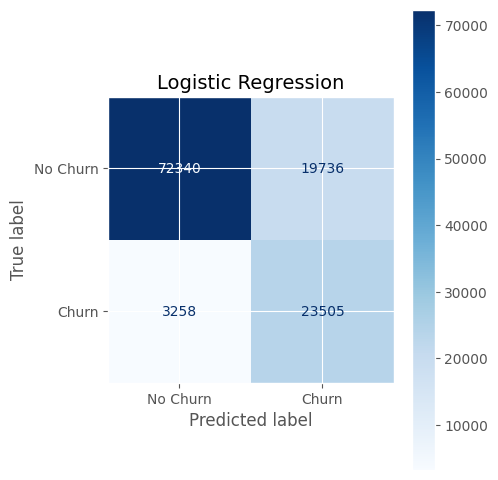

Logistic Regression
True Negatives : 72340
False Positives: 19736
False Negatives: 3258
True Positives : 23505


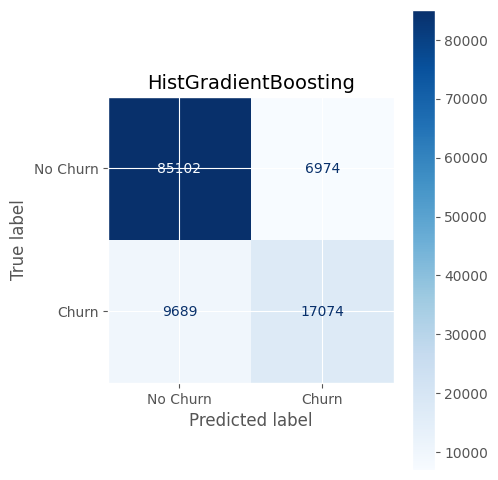

HistGradientBoosting
True Negatives : 85102
False Positives: 6974
False Negatives: 9689
True Positives : 17074


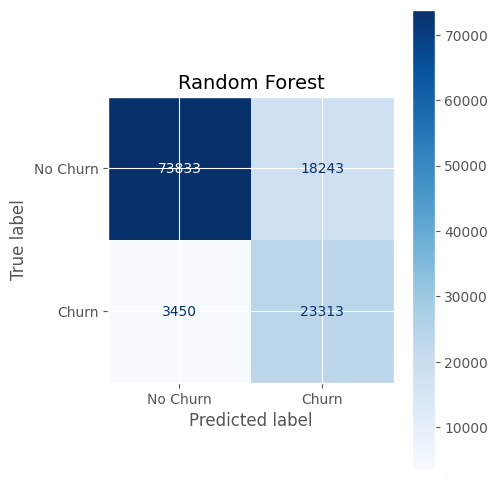

Random Forest
True Negatives : 73833
False Positives: 18243
False Negatives: 3450
True Positives : 23313


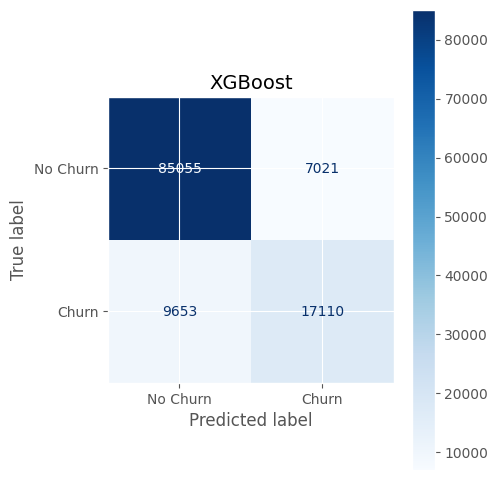

XGBoost
True Negatives : 85055
False Positives: 7021
False Negatives: 9653
True Positives : 17110


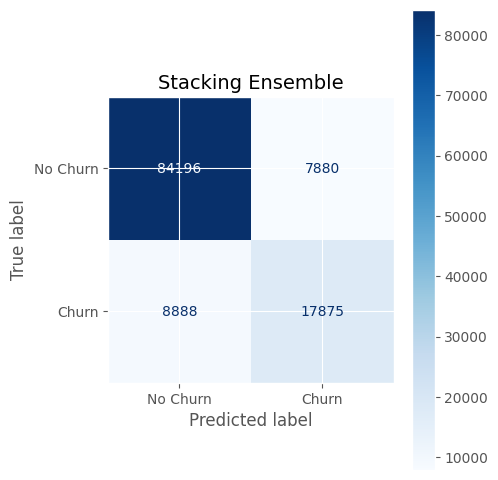

Stacking Ensemble
True Negatives : 84196
False Positives: 7880
False Negatives: 8888
True Positives : 17875


In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": y_val_pred,
    "HistGradientBoosting": gb_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "Stacking Ensemble": stack_pred
}

for model_name, pred in models.items():

    cm = confusion_matrix(y_val, pred)

    fig, ax = plt.subplots(figsize=(5, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot(ax=ax, cmap="Blues", values_format="d")
    ax.set_title(model_name)

    plt.tight_layout()
    plt.show()

    tn, fp, fn, tp = cm.ravel()

    print("=" * 40)
    print(model_name)
    print("=" * 40)
    print(f"True Negatives : {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    print(f"True Positives : {tp}")

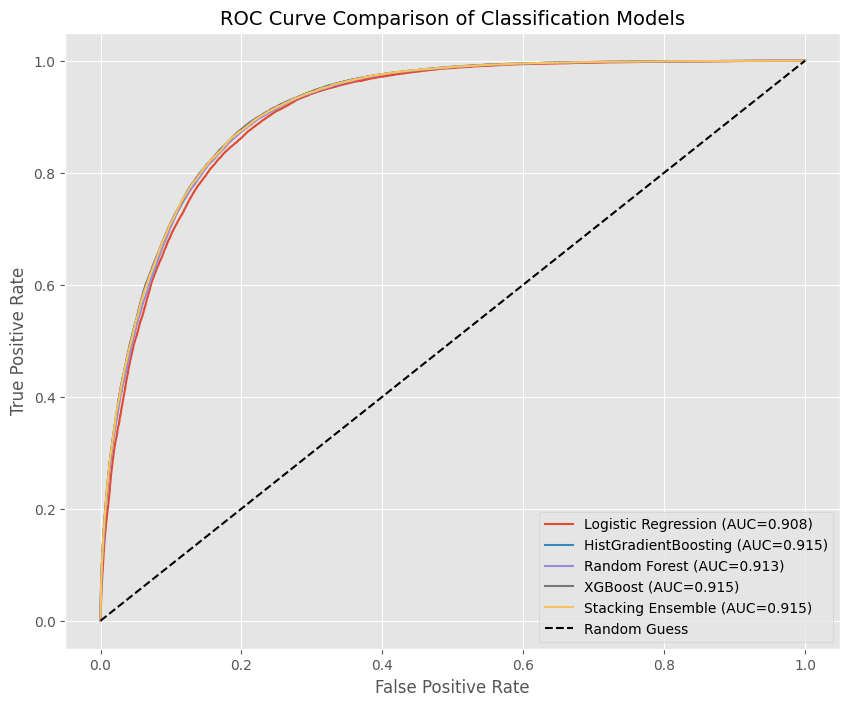

In [96]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# Logistic Regression
lr_prob = logistic_model.predict_proba(X_val_processed)[:, 1]
lr_fpr, lr_tpr, _ = roc_curve(y_val, lr_prob)
lr_auc = roc_auc_score(y_val, lr_prob)
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC={lr_auc:.3f})')

# HistGradientBoosting
hgb_prob = gb_model.predict_proba(X_val_processed)[:, 1]
hgb_fpr, hgb_tpr, _ = roc_curve(y_val, hgb_prob)
hgb_auc = roc_auc_score(y_val, hgb_prob)
plt.plot(hgb_fpr, hgb_tpr, label=f'HistGradientBoosting (AUC={hgb_auc:.3f})')

# Random Forest
rf_prob = rf_model.predict_proba(X_val_processed)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_val, rf_prob)
rf_auc = roc_auc_score(y_val, rf_prob)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={rf_auc:.3f})')

# XGBoost
xgb_prob = xgb_model.predict_proba(X_val_processed)[:, 1]
xgb_fpr, xgb_tpr, _ = roc_curve(y_val, xgb_prob)
xgb_auc = roc_auc_score(y_val, xgb_prob)
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC={xgb_auc:.3f})')

# Stacking Ensemble
stack_prob = stack_model.predict_proba(X_val_processed)[:, 1]
stack_fpr, stack_tpr, _ = roc_curve(y_val, stack_prob)
stack_auc = roc_auc_score(y_val, stack_prob)
plt.plot(stack_fpr, stack_tpr, label=f'Stacking Ensemble (AUC={stack_auc:.3f})')

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison of Classification Models')
plt.legend(loc='lower right')
plt.grid(True)

plt.show()

<Figure size 1000x800 with 0 Axes>

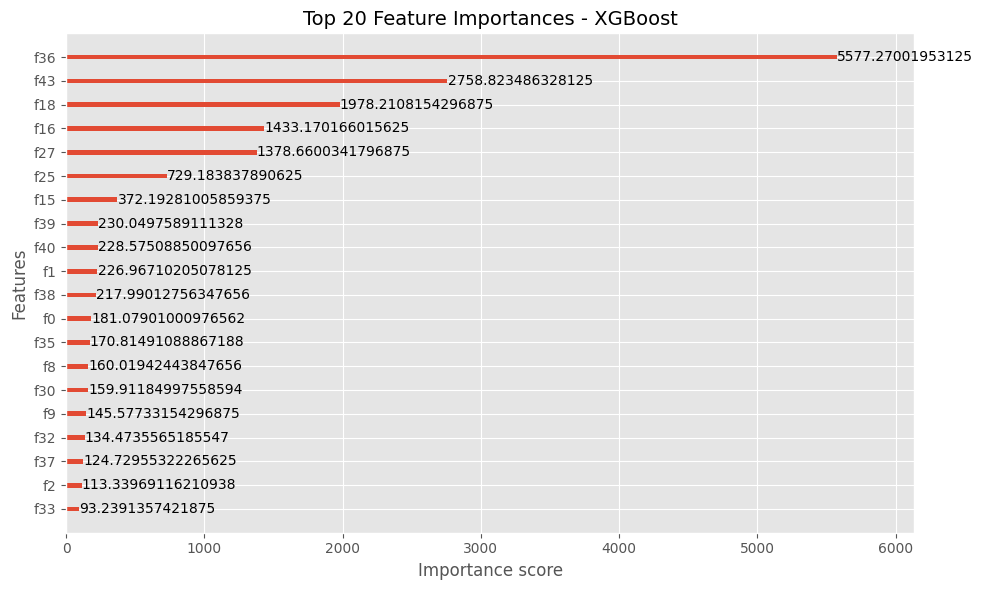

In [100]:

from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plot_importance(
    xgb_model,
    importance_type="gain",
    max_num_features=20
)

plt.title("Top 20 Feature Importances - XGBoost")
plt.tight_layout()
plt.show()

In [101]:
X_test_processed = preprocessor.transform(test_data)

test_probs = xgb_model.predict_proba(X_test_processed)[:, 1]

submission = pd.DataFrame({
    "id": test_data["id"],
    "Churn": (test_probs >= best_thresh).astype(int)
})

submission.to_csv("submission.csv", index=False)

In [102]:
import joblib
import os

save_dir = r"D:\\DATA SCience\\semester 3\\CIS6005\\BSc DS - CIS- 6005- 20286254\\Customer_Churn_Prediction\\models"

os.makedirs(save_dir, exist_ok=True)

joblib.dump(xgb_model, os.path.join(save_dir, "xgb_model.pkl"))

joblib.dump(preprocessor, os.path.join(save_dir, "preprocessor.pkl"))

print("Model saved successfully to:", save_dir)

Model saved successfully to: D:\\DATA SCience\\semester 3\\CIS6005\\BSc DS - CIS- 6005- 20286254\\Customer_Churn_Prediction\\models


In [103]:
print(list(preprocessor.feature_names_in_))

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
